Veri Setinin Hikayesi:
Bu veri seti, ayı türlerinin genom dizilerini içerir. Veriler GenBank veritabanından çekilmiş olup, her bir tür için genetik açıklamalar ve diziler yer almaktadır. Genetik diziler ve açıklamalar, biyolojik araştırmaların yapılması, genetik çeşitliliğin incelenmesi veya ayı türlerinin evrimsel ilişkilerinin analiz edilmesi için kullanılabilir. Verilerin özellikleri arasında GC içeriği, dizi uzunluğu ve baz frekansları yer alabilir, bu da genom verisinin biyolojik anlamda daha derin bir şekilde analiz edilmesine olanak sağlar.


Ursus Türleri ve Genetik Araştırmaların Önemi
Ursus cinsi, ayıların içinde yer alan ve ekosistemlerde önemli bir rol üstlenen büyük memelilerdir. Bu cins, Ursus arctos (kahverengi ayı), Ursus maritimus (kutup ayısı), Ursus americanus (siyah ayı) gibi türleri içerir. Ayılar, genellikle üst düzey yırtıcılar olarak bilinir ve doğada dengeyi sağlamak için kritik bir işlevi vardır. Bu türlerin genomik verilerinin toplanması, onların evrimsel tarihini, biyolojik çeşitliliğini, adaptasyonlarını ve ekosistem üzerindeki etkilerini daha iyi anlamamıza olanak tanır.

 NCBI GenBank **Ayı** türlerinin genomik verileri de bu veritabanında yer almaktadır. Ursus türleri üzerine yapılan genetik araştırmalar, bu hayvanların hastalıklarla savaşma yeteneklerini, iklim değişikliklerine nasıl tepki verdiklerini, evrimsel adaptasyonlarını ve biyolojik çeşitliliklerini incelemek için hayati öneme sahiptir.

Kaynaklar:
NCBI GenBank: NCBI, biyoteknoloji araştırmalarına katkıda bulunarak, biyolojik çeşitliliği koruma ve bilimsel keşifler yapma amacı taşır. Ayı türlerinin genom verileri burada yer alır. NCBI GenBank.

Ursus maritimus (Kutup Ayısı): https://www.ncbi.nlm.nih.gov/nucleotide/?term=Ursus+maritimus[Organism]

Ursus arctos (Kahverengi Ayı): https://www.ncbi.nlm.nih.gov/nucleotide/?term=Ursus+arctos[Organism]

Ursus americanus (Amerikan Siyah Ayı): https://www.ncbi.nlm.nih.gov/nucleotide/?term=Ursus+americanus[Organism]

Ursus thibetanus (Asya Siyah Ayı): https://www.ncbi.nlm.nih.gov/nucleotide/?term=Ursus+thibetanus[Organism]

Ursus malayanus (Malay Ayısı): https://www.ncbi.nlm.nih.gov/nucleotide/?term=Ursus+malayanus[Organism]

Ursus ornatus (Süslenmiş ayı): https://www.ncbi.nlm.nih.gov/nucleotide/?term=Ursus+ornatus[Organism]



In [ ]:
pip install biopython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 26.1 MB/s eta 0:00:00


In [114]:
from Bio import Entrez, SeqIO
import pandas as pd
import re

# NCBI'ye e-posta ile kimliğinizi tanıtın
Entrez.email = "x@gmail.com"  # Kendi e-posta adresinizi yazın

# Ayı türleri listesi
species_list = [
    "Ursus maritimus",  # Polar Bear
    "Ursus arctos",  # Brown Bear
    "Ursus americanus",  # American Black Bear
    "Ursus thibetanus",  # Asiatic Black Bear
    "Ursus malayanus",  # Malayan Sun Bear
    "Ursus ornatus"  # Andean Bear
]


# GenBank verilerini çekmek için fonksiyon
def fetch_genomic_data(species):
    search_term = f"{species}[Organism]"  # Tür adıyla arama yapıyoruz
    handle = Entrez.esearch(db="nucleotide", term=search_term, retmax=5)  # Max 5 sonuç alıyoruz
    record = Entrez.read(handle)
    handle.close()

    # ID'leri alıyoruz
    id_list = record["IdList"]
    genbank_records = []

    # Kayıtlardan verileri alıyoruz
    for id in id_list:
        handle = Entrez.efetch(db="nucleotide", id=id, rettype="gb", retmode="text")
        genbank_records.append(handle.read())
        handle.close()

    return genbank_records

# Genom verilerini almak ve işlemek
data_list = []
for species in species_list:
    print(f"Fetching genomic data for {species}...")

    genbank_records = fetch_genomic_data(species)

    # Her bir GenBank kaydını işliyoruz
    for record in genbank_records:
        lines = record.splitlines()
        gene_name = None
        description = None
        sequence = None

        for line in lines:
            if line.startswith("DEFINITION"):
                description = line.split(" ", 1)[1]  # İlk boşluktan sonrasını al
            if "/gene=" in line:
                gene_match = re.search(r'/gene="([^"]+)"', line)
                if gene_match:
                    gene_name = gene_match.group(1)  # İlgili gene ismini bul
            if line.startswith("ORIGIN"):
                sequence_start = lines.index(line) + 1
                sequence = "".join("".join(lines[sequence_start:]).split())  # Diziyi birleştirin

        # Verileri data_list'e ekleyin
        data = {
            "Species": species,
            "Gene": gene_name if gene_name else "Not found",
            "Description": description if description else "Not found",
            "Sequence": sequence if sequence else "Not found"
        }
        data_list.append(data)

# DataFrame oluşturun ve CSV olarak kaydedin
df = pd.DataFrame(data_list)
df.to_csv('bear_genomes_all_species.csv', index=False)
print("Genomic data for all species has been saved to bear_genomes_all_species.csv")


Fetching genomic data for Ursus maritimus...
Fetching genomic data for Ursus arctos...
Fetching genomic data for Ursus americanus...
Fetching genomic data for Ursus thibetanus...
Fetching genomic data for Ursus malayanus...
Fetching genomic data for Ursus ornatus...
Genomic data for all species has been saved to bear_genomes_all_species.csv


In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
# Örnek bir dosya adı, indirdiğiniz dosya adı ile değiştirin
data = pd.read_csv('/content/bear_genomes_all_species.csv')  # veya uygun dosya uzantısını kullanın

           Species       Gene  \
0  Ursus maritimus      GPR84   
1  Ursus maritimus      GPR84   
2  Ursus maritimus       PRNP   
3  Ursus maritimus  Not found   
4  Ursus maritimus  Not found   

                                         Description  \
0   Ursus maritimus G-protein coupled receptor 84...   
1   Ursus maritimus G protein-coupled receptor 84...   
2   TPA_inf: Ursus maritimus prion protein (PRNP)...   
3   Ursus maritimus isolate um76 tRNA-Pro gene an...   
4   Ursus maritimus isolate nz4 tRNA-Pro gene and...   

                                            Sequence  
0  1atgcagaacaccagtgccacgttctcctgctaccattcgtctgta...  
1  1atgaacccgcaccagcagcagaatcattttctggaaatagacaac...  
2  1atggtgaaaagccacataggcggctggatcctggttctctttgtg...  
3  1aactattccctggtacatactactattttactccatgtcctattc...  
4  1aactattccctggtacatactactattttactccatgtcctattc...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count

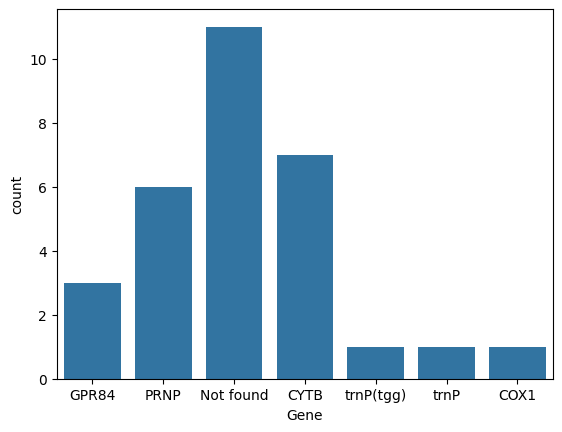

In [117]:
# İlk birkaç satırı görüntüle
print(data.head())

# Veri çerçevesinin bilgilerini kontrol et
print(data.info())

# Verideki eksik değerlere bak
print(data.isnull().sum())

# Basit istatistikler
print(data.describe())

# Görselleştirme
sns.countplot(x='Gene', data=data)  # 'desired_column' ile hedef sütun adını değiştirin.
plt.show()

In [118]:
print(data.columns)

Index(['Species', 'Gene', 'Description', 'Sequence'], dtype='object')


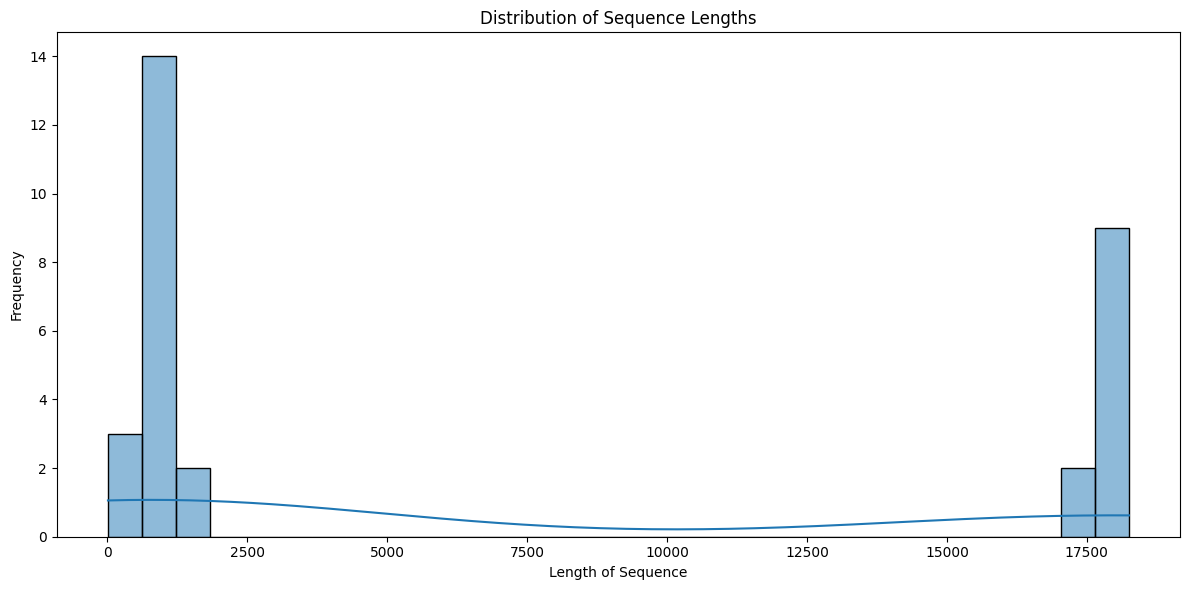

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
# 'Sequence' sütunundaki dizilerin uzunluklarını hesaplama
df['Sequence Length'] = df['Sequence'].apply(len)

# Dizilerin uzunluklarının histogramını oluşturma
plt.figure(figsize=(12, 6))
sns.histplot(df['Sequence Length'], bins=30, kde=True)
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Length of Sequence')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

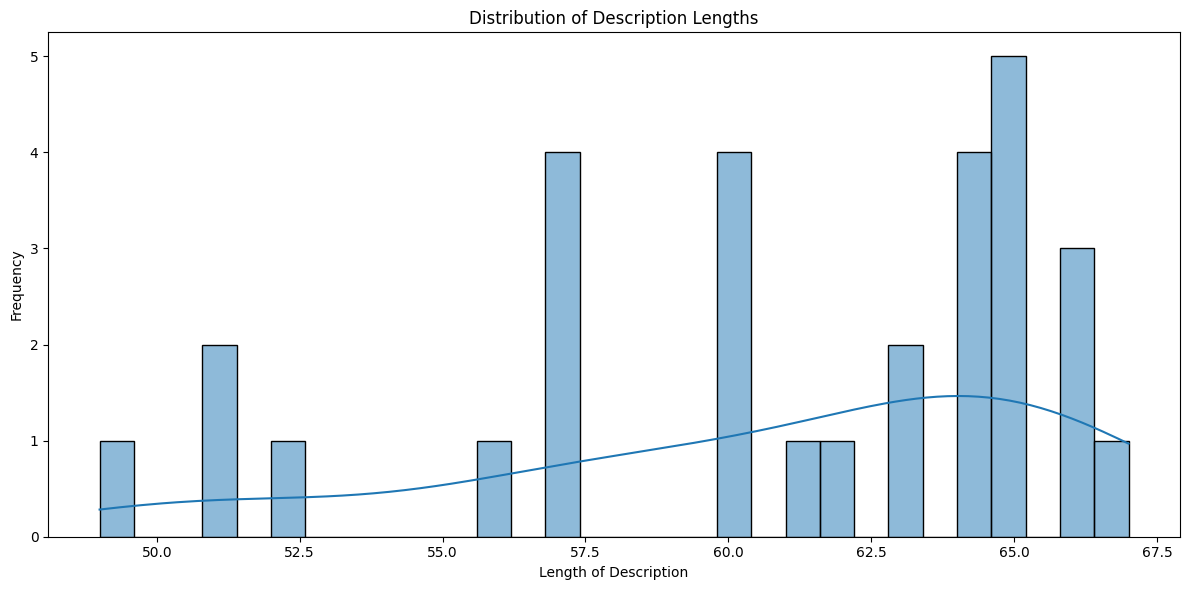

In [120]:
# 'Description' sütunundaki açıklamaların uzunluklarını hesaplama
df['Description Length'] = df['Description'].apply(len)

# Açıklama uzunluklarının histogramını oluşturma
plt.figure(figsize=(12, 6))
sns.histplot(df['Description Length'], bins=30, kde=True)
plt.title('Distribution of Description Lengths')
plt.xlabel('Length of Description')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

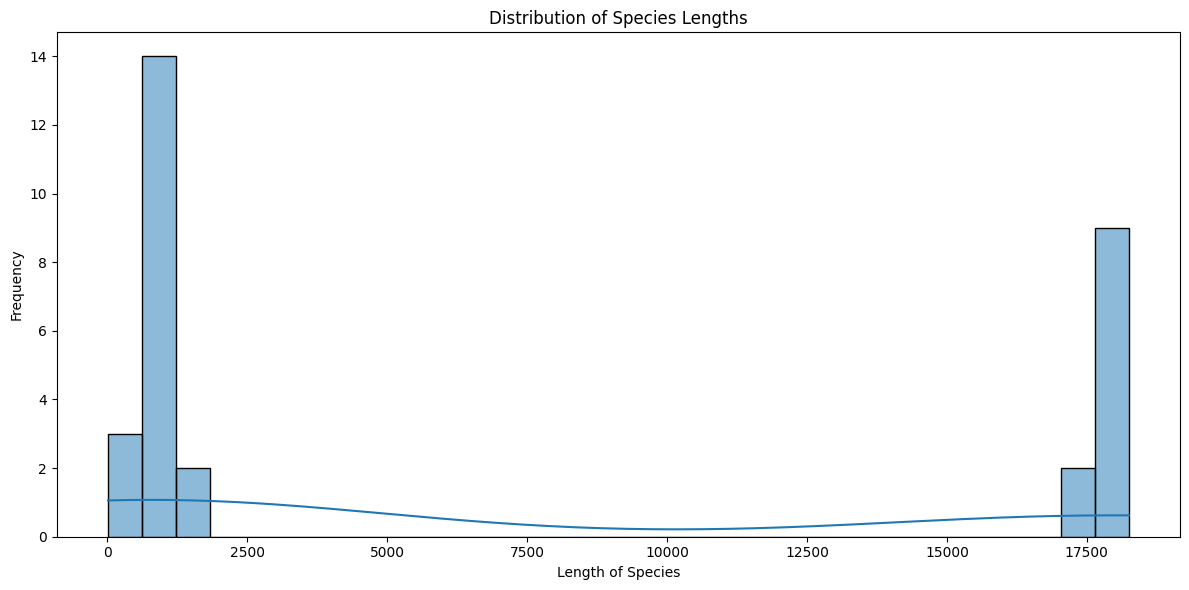

In [121]:

import seaborn as sns
import matplotlib.pyplot as plt
# 'Species' sütunundaki dizilerin uzunluklarını hesaplama
df['Species Length'] = df['Species'].apply(len)

# Dizilerin uzunluklarının histogramını oluşturma
plt.figure(figsize=(12, 6))
sns.histplot(df['Sequence Length'], bins=30, kde=True)
plt.title('Distribution of Species Lengths')
plt.xlabel('Length of Species')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

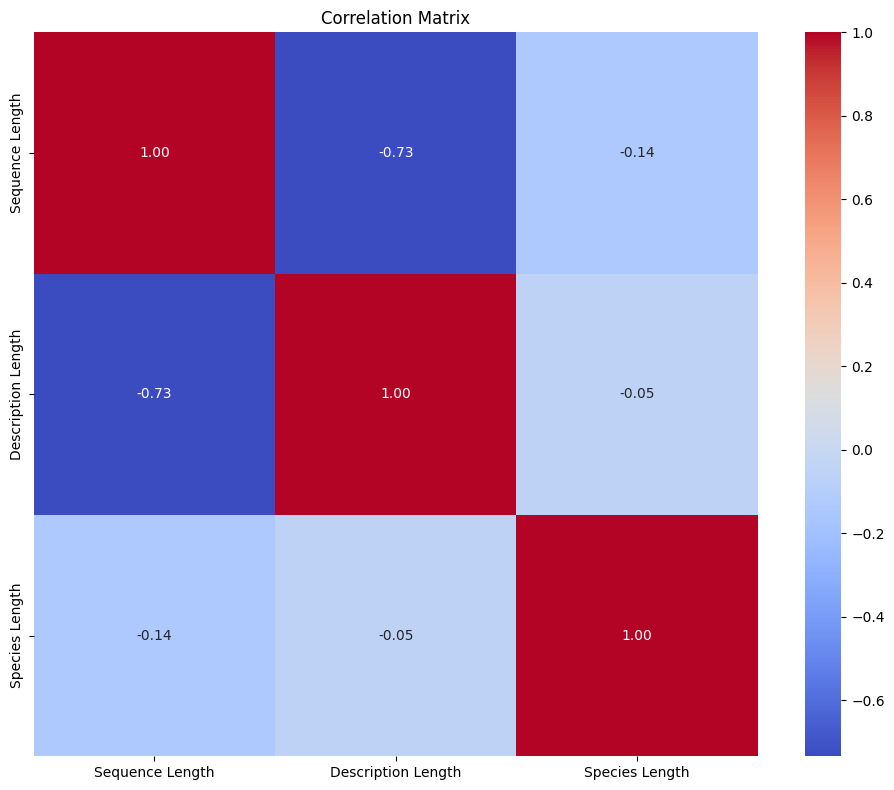

In [122]:
## Sayısal değişkenleri seçme (string olmayanlara odaklanma)
numeric_df = df.select_dtypes(include='number')

# Sayısal değişkenler arasında korelasyon matrisini hesaplama
correlation_matrix = numeric_df.corr()

# Korelasyon matrisinin ısı haritasını oluşturma
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()
plt.show()

In [123]:
from sklearn.preprocessing import LabelEncoder

# Hedef değişkeni sayısallaştırma
label_encoder = LabelEncoder()
data['Gene'] = label_encoder.fit_transform(data['Gene'])  # Metinleri sayısal değerlere çevir

# Dönüştürülen etiketleri incelemek için
print(label_encoder.classes_)  # Orijinal sınıf isimlerini gösterir


['COX1' 'CYTB' 'GPR84' 'Not found' 'PRNP' 'trnP' 'trnP(tgg)']


In [124]:
print(data.columns)


Index(['Species', 'Gene', 'Description', 'Sequence'], dtype='object')


In [125]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from Bio import SeqIO
import pandas as pd
import numpy as np

# Veriyi yükleyin
df = pd.read_csv('bear_genomes_all_species.csv')

# GC içeriğini hesaplayan fonksiyon
def calculate_gc_content(sequence):
    g_count = sequence.count('G')
    c_count = sequence.count('C')
    return (g_count + c_count) / len(sequence) * 100

# Dizi uzunluğunu hesaplayan fonksiyon
def calculate_sequence_length(sequence):
    return len(sequence)

# Baz sıklıklarını hesaplayan fonksiyon
def calculate_base_frequencies(sequence):
    bases = ['A', 'T', 'C', 'G']
    freqs = {base: sequence.count(base) / len(sequence) if len(sequence) > 0 else 0 for base in bases}
    return freqs

# Genetik diziler için öznitelikler çıkarımı
df['GC_Content'] = df['Sequence'].apply(lambda x: calculate_gc_content(x) if x != "Not found" else 0)
df['Sequence_Length'] = df['Sequence'].apply(lambda x: calculate_sequence_length(x) if x != "Not found" else 0)

# Baz frekanslarını çıkaralım
base_freqs = df['Sequence'].apply(lambda x: calculate_base_frequencies(x) if x != "Not found" else {base: 0 for base in ['A', 'T', 'C', 'G']})
base_freqs_df = pd.DataFrame(base_freqs.tolist(), columns=['A_Frequency', 'T_Frequency', 'C_Frequency', 'G_Frequency'])

# Ana veri çerçevesine baz frekanslarını ekleyelim
df = pd.concat([df, base_freqs_df], axis=1)

# Label encoding: türleri sayısal değerlere dönüştürme
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Species_Label'] = label_encoder.fit_transform(df['Species'])

# Özellikler ve hedef değişkeni
X = df[['GC_Content', 'Sequence_Length', 'A_Frequency', 'T_Frequency', 'C_Frequency', 'G_Frequency']]  # Yeni çıkarılmış öznitelikler
y = df['Species_Label']  # Hedef (Tür)

# Eğitim ve test verisine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest için hiperparametre optimizasyonu yapalım
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid,
                           cv=3, verbose=2, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# En iyi parametreleri ve doğruluğu yazdıralım
print("En iyi parametreler:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

# Modeli test verisiyle değerlendirelim
y_pred = best_rf_model.predict(X_test)

# Model değerlendirme
print("Doğruluk Skoru:", accuracy_score(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Türleri tekrar orijinal isimlerine dönüştürme
y_pred_species = label_encoder.inverse_transform(y_pred)
y_test_species = label_encoder.inverse_transform(y_test)

# Sonuçları görüntüleme
result_df = pd.DataFrame({'True Species': y_test_species, 'Predicted Species': y_pred_species})
print(result_df.head())


Fitting 3 folds for each of 216 candidates, totalling 648 fits
En iyi parametreler: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Doğruluk Skoru: 0.6666666666666666

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       0.33      1.00      0.50         1
           4       1.00      1.00      1.00         1
           5       0.00      0.00      0.00         2

    accuracy                           0.67         6
   macro avg       0.58      0.75      0.62         6
weighted avg       0.56      0.67      0.58         6

       True Species Predicted Species
0     Ursus ornatus     Ursus ornatus
1  Ursus thibetanus   Ursus malayanus
2   Ursus malayanus   Ursus malayanus
3  Ursus thibetanus   Ursus malayanus
4      Ursus arctos      Ursus arctos


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
